In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import plotly.graph_objects as go
import logging
import ast
import math
from collections import Counter
import random
from torch.nn.utils.rnn import pad_sequence

import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset

# Display the correlation matrix to the user
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import utils
import z_utils

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = "cpu"
print(device)
spike_df = pd.read_csv('../../Data_processed/spike_tensors_x.csv')
spike_df['spike_durations'] = spike_df['spike_durations'].apply(ast.literal_eval)
# spike_df['spike_durations'] = spike_df['spike_durations'].apply(lambda x: x + [0]*(4-len(x)))

spike_df['spike_magnitudes'] = spike_df['spike_magnitudes'].apply(ast.literal_eval)
# spike_df['spike_magnitudes'] = spike_df['spike_magnitudes'].apply(lambda x: x + [0.0]*(4-len(x)))

spike_df['time'] = spike_df['spike_times_intervals'].apply(ast.literal_eval)
spike_df['time'] = spike_df['time'].apply(lambda x: x + [0]*(4-len(x)))

print(spike_df.head())

cuda
   spike_num    spike_type spike_durations              spike_magnitudes  \
0          3     [2, 2, 3]       [3, 3, 4]         [0.663, 0.493, 0.886]   
1          2     [3, 2, 3]          [4, 5]                [0.933, 1.306]   
2          2     [2, 2, 3]          [6, 9]                [1.191, 1.085]   
3          4  [3, 2, 2, 3]    [3, 3, 3, 3]  [1.075, 0.551, 0.695, 1.164]   
4          3  [2, 3, 2, 3]       [3, 3, 5]         [0.408, 0.991, 1.413]   

                                       ID-statistics  \
0  [0.2525107493475829, 0.158, 0.2470795043314368...   
1  [0.2525107493475829, 0.158, 0.2470795043314368...   
2  [0.2525107493475829, 0.158, 0.2470795043314368...   
3  [0.2525107493475829, 0.158, 0.2470795043314368...   
4  [0.2525107493475829, 0.158, 0.2470795043314368...   

                                             weather spike_times_intervals  \
0  [0.44636145833333335, 0.3711697916666667, 0.66...          [24, 34, 38]   
1  [0.37326145833333335, 0.1712510416666667, 

# Spike Number

In [5]:
num_df = spike_df[['spike_num', 'ID-statistics', 'weather', 'date_sin', 'date_cos']]

num_df.loc[:, 'ID-statistics']  = num_df['ID-statistics'].apply(ast.literal_eval)
num_df.loc[:, 'weather'] = num_df['weather'].apply(ast.literal_eval)

id_stats_df = pd.DataFrame(num_df['ID-statistics'].tolist(), columns=[f'ID_stat_{i}' for i in range(6)])
weather_df = pd.DataFrame(num_df['weather'].tolist(), columns=[f'weather_{i}' for i in range(3)])

# Combine the features into one dataframe
features_df = pd.concat([num_df[['spike_num', 'date_sin', 'date_cos']], id_stats_df, weather_df], axis=1)

print(features_df.head())

   spike_num  date_sin  date_cos  ID_stat_0  ID_stat_1  ID_stat_2  ID_stat_3  \
0          3 -0.977848  0.209315   0.252511      0.158    0.24708        0.0   
1          2 -0.974100  0.226116   0.252511      0.158    0.24708        0.0   
2          2 -0.970064  0.242850   0.252511      0.158    0.24708        0.0   
3          4 -0.965740  0.259512   0.252511      0.158    0.24708        0.0   
4          3 -0.961130  0.276097   0.252511      0.158    0.24708        0.0   

   ID_stat_4  ID_stat_5  weather_0  weather_1  weather_2  
0      2.994   0.109262   0.446361   0.371170   0.665174  
1      2.994   0.109262   0.373261   0.171251   0.805466  
2      2.994   0.109262   0.351654   0.176619   0.733635  
3      2.994   0.109262   0.392647   0.228449   0.797481  
4      2.994   0.109262   0.452847   0.391402   0.658953  


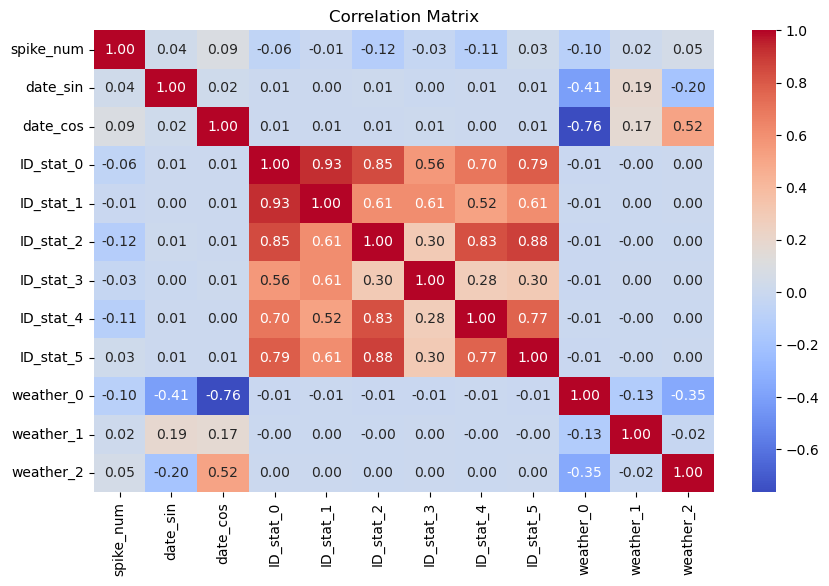

In [6]:
# Compute correlation matrix
correlation_matrix = features_df.corr()

# Assuming 'correlation_matrix' is your pandas DataFrame
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


In [7]:
spike_num = features_df['spike_num']
# spike_num_norm = (spike_num - spike_num.mean()) / spike_num.std()
spike_num_norm = spike_num - 6

mean_temp = features_df['ID_stat_0']
mean_temp_norm = (mean_temp - mean_temp.mean()) / mean_temp.std()

median_temp = features_df['ID_stat_1']
median_temp_norm = (median_temp - median_temp.mean()) / median_temp.std()

std_temp = features_df['ID_stat_2']
std_temp_norm = (std_temp - std_temp.mean()) / std_temp.std()

min_temp = features_df['ID_stat_3']
min_temp_norm = (min_temp - min_temp.mean()) / min_temp.std()

max_temp = features_df['ID_stat_4']
max_temp_norm = (max_temp - max_temp.mean()) / max_temp.std()

gradient_temp = features_df['ID_stat_5']
gradient_temp_norm = (gradient_temp - gradient_temp.mean()) / gradient_temp.std()

date_sin = features_df['date_sin']
# date_sin_norm = (date_sin - date_sin.mean()) / date_sin.std()
date_sin_norm = date_sin

date_cos = features_df['date_cos']
# date_cos_norm = (date_cos - date_cos.mean()) / date_cos.std()
date_cos_norm = date_cos

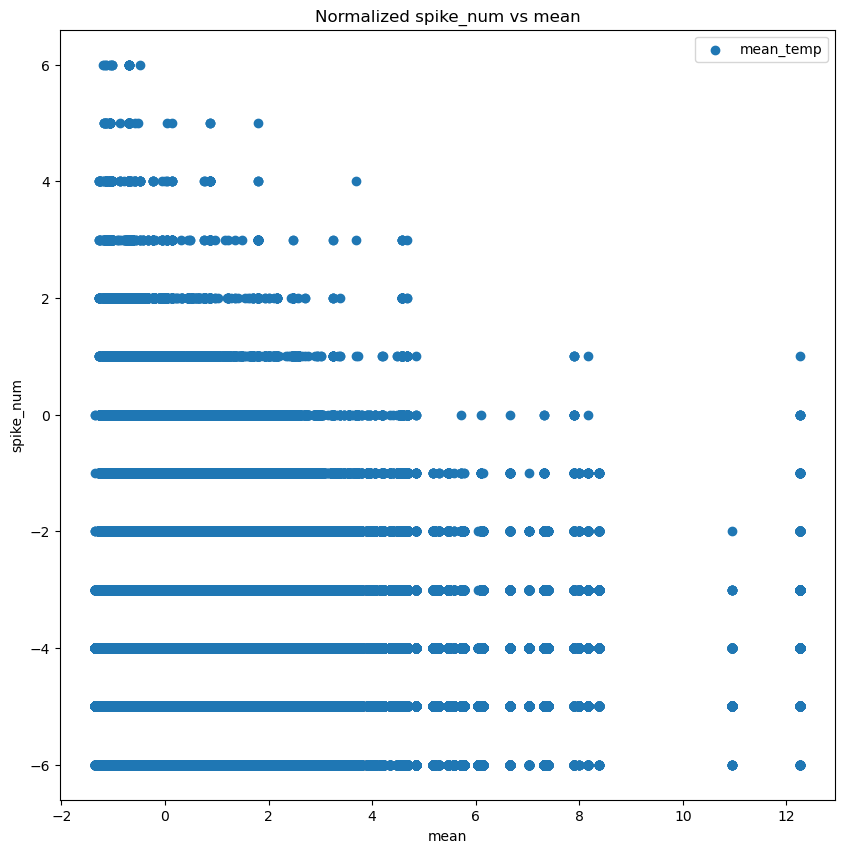

In [8]:
plt.figure(figsize=(10, 10))
plt.scatter(mean_temp_norm, spike_num_norm, label='mean_temp')
plt.title('Normalized spike_num vs mean')
plt.xlabel('mean')
plt.ylabel('spike_num')
plt.legend()
plt.show()

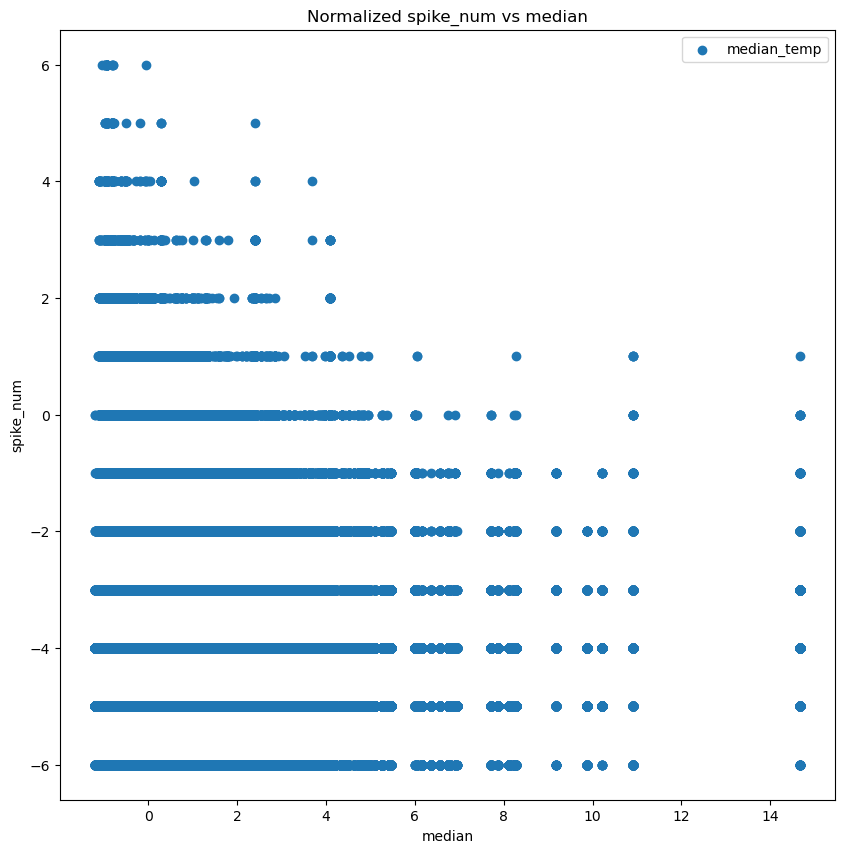

In [9]:
plt.figure(figsize=(10, 10))
plt.scatter(median_temp_norm, spike_num_norm, label='median_temp')
plt.title('Normalized spike_num vs median')
plt.xlabel('median')
plt.ylabel('spike_num')
plt.legend()
plt.show()

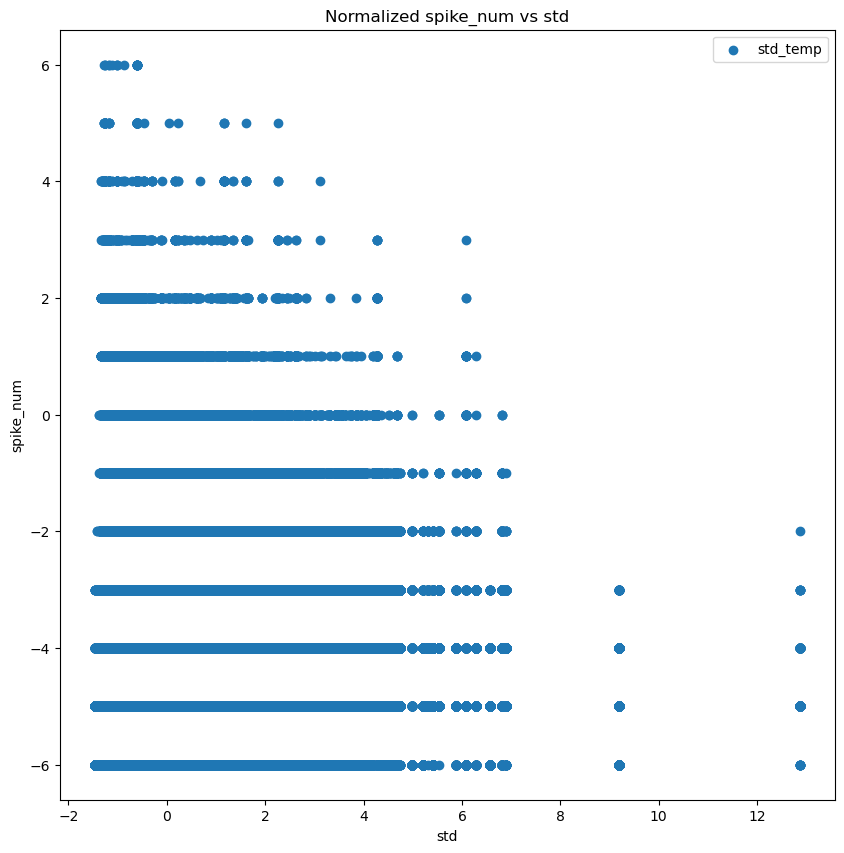

In [10]:
plt.figure(figsize=(10, 10))
plt.scatter(std_temp_norm, spike_num_norm, label='std_temp')
plt.title('Normalized spike_num vs std')
plt.xlabel('std')
plt.ylabel('spike_num')
plt.legend()
plt.show()

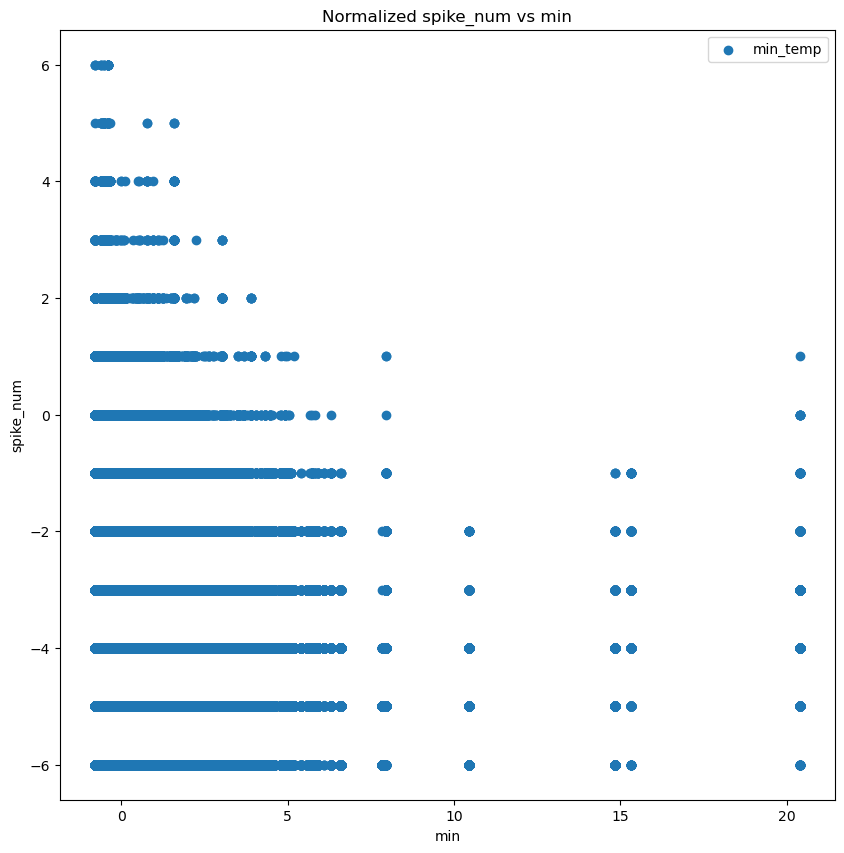

In [11]:
plt.figure(figsize=(10, 10))
plt.scatter(min_temp_norm, spike_num_norm, label='min_temp')
plt.title('Normalized spike_num vs min')
plt.xlabel('min')
plt.ylabel('spike_num')
plt.legend()
plt.show()

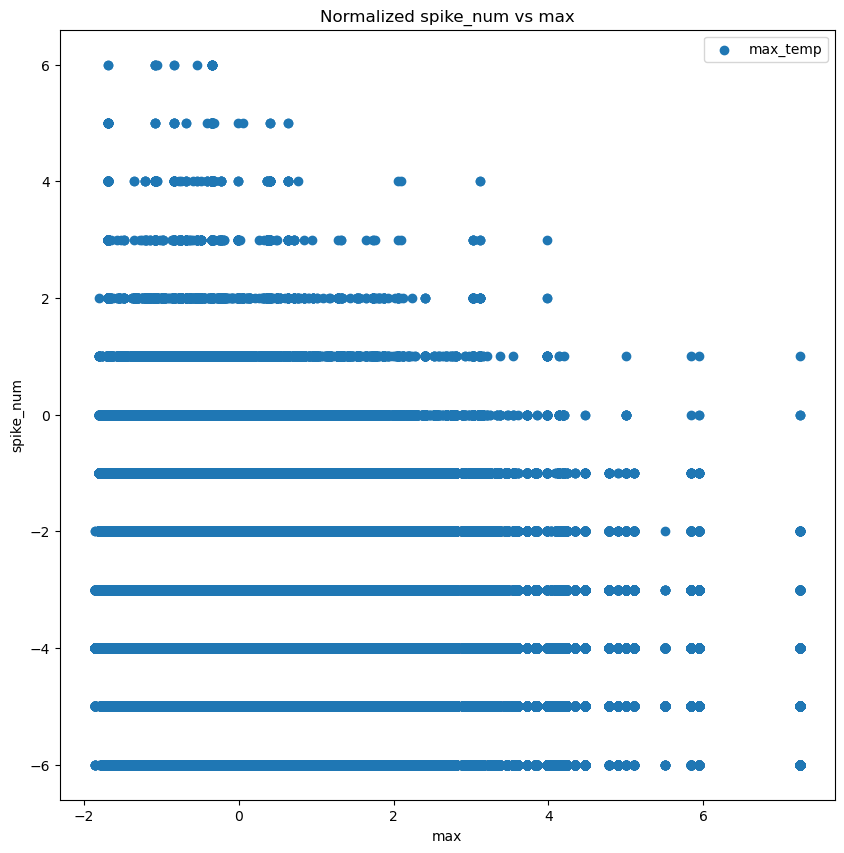

In [12]:
plt.figure(figsize=(10, 10))
plt.scatter(max_temp_norm, spike_num_norm, label='max_temp')
plt.title('Normalized spike_num vs max')
plt.xlabel('max')
plt.ylabel('spike_num')
plt.legend()
plt.show()

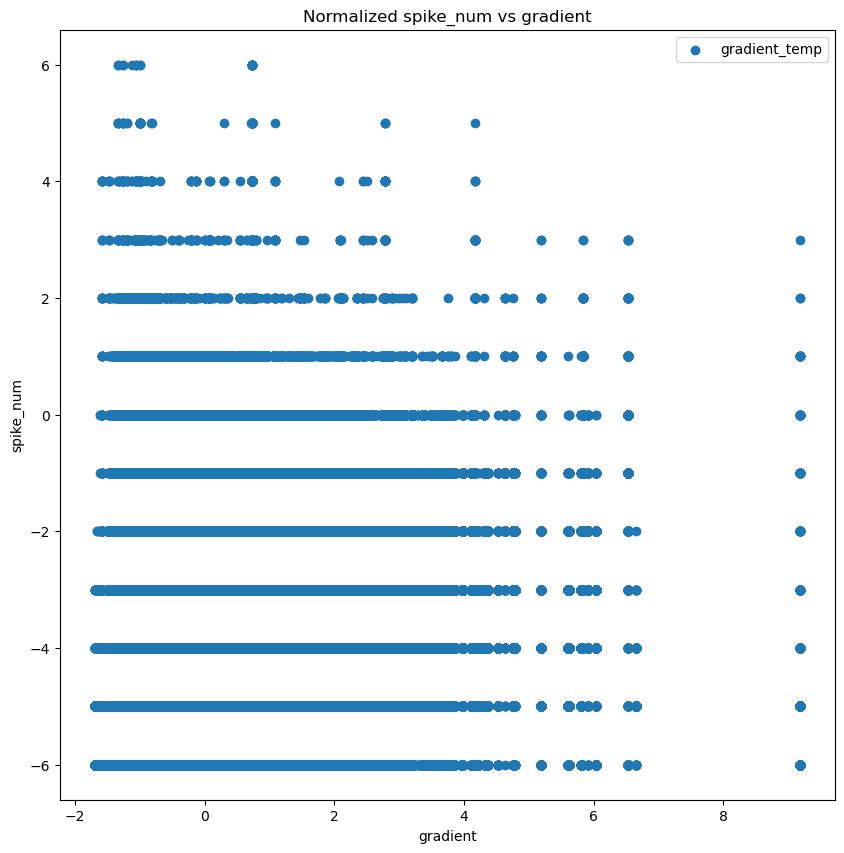

In [13]:
plt.figure(figsize=(10, 10))   
plt.scatter(gradient_temp_norm, spike_num_norm, label='gradient_temp')
plt.title('Normalized spike_num vs gradient')
plt.xlabel('gradient')
plt.ylabel('spike_num')
plt.legend()
plt.show()

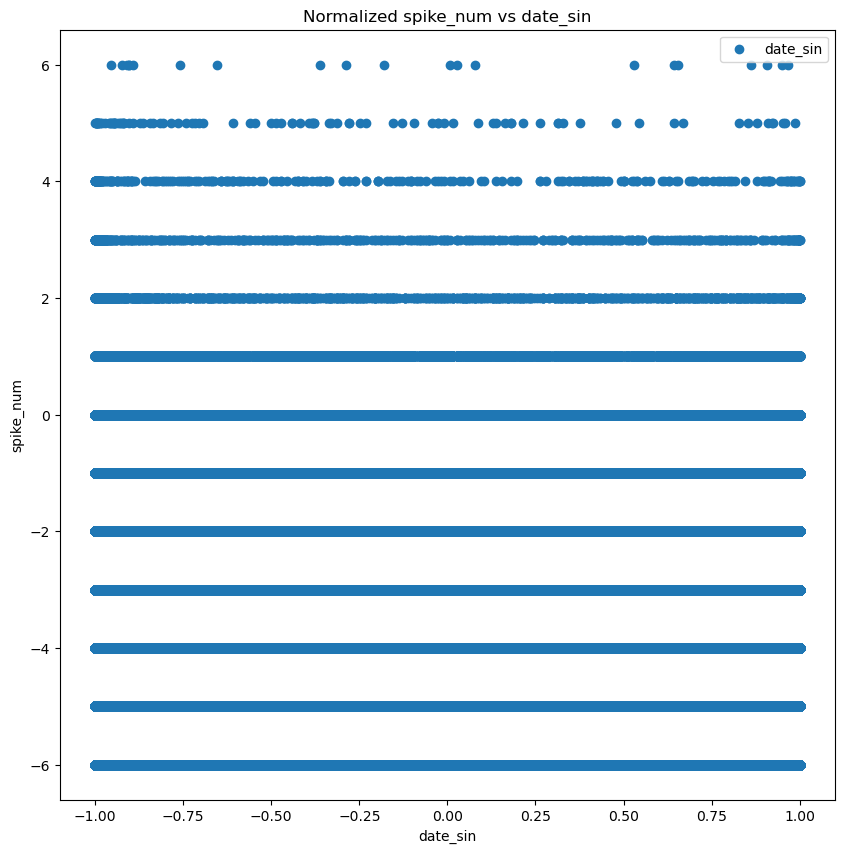

In [14]:
plt.figure(figsize=(10, 10))
plt.scatter(date_sin_norm, spike_num_norm, label='date_sin')
plt.title('Normalized spike_num vs date_sin')
plt.xlabel('date_sin')
plt.ylabel('spike_num')
plt.legend()
plt.show()

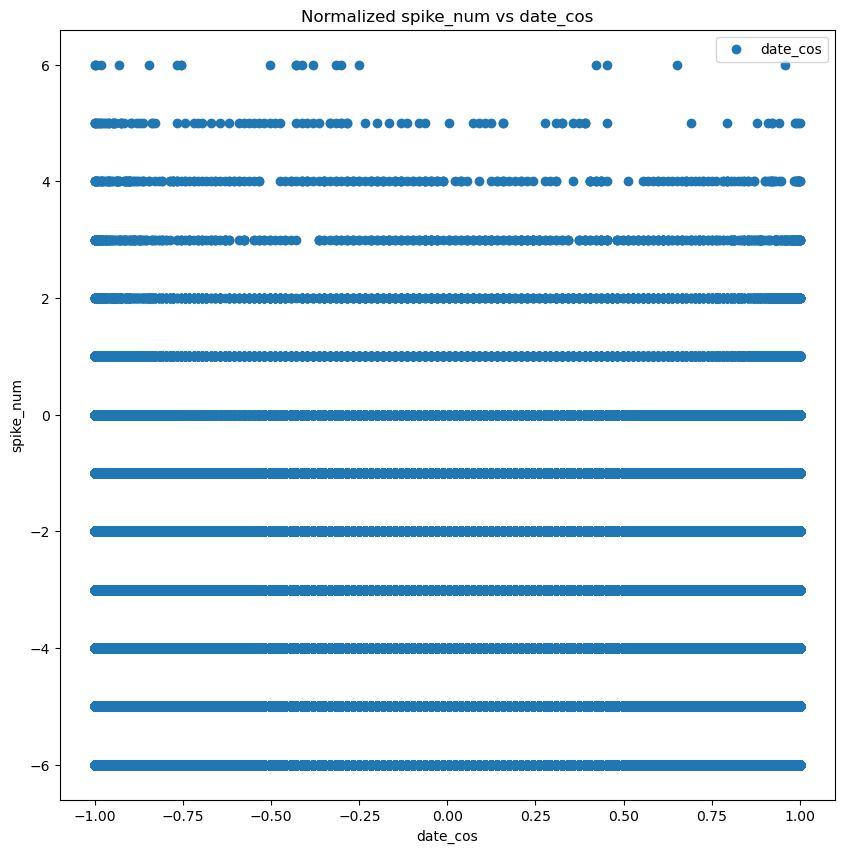

In [15]:
plt.figure(figsize=(10, 10))
plt.scatter(date_cos_norm, spike_num_norm, label='date_cos')
plt.title('Normalized spike_num vs date_cos')
plt.xlabel('date_cos')
plt.ylabel('spike_num')
plt.legend()
plt.show()

In [16]:
# Average the 6 values in ID-statistics to create a single feature
id_stats_avg = features_df[[f'ID_stat_{i}' for i in range(6)]].mean(axis=1)

# Normalize the ID-stat feature
id_stats_norm = (id_stats_avg - id_stats_avg.mean()) / id_stats_avg.std()

# Compute correlation between normalized spike_num and normalized ID_stat
correlation = np.corrcoef(spike_num_norm, id_stats_norm)[0, 1]

# Display correlation value
correlation

-0.09900446782130248

In [17]:
weather_avg = features_df[[f'weather_{i}' for i in range(3)]].mean(axis=1)
weather_norm = (weather_avg - weather_avg.mean()) / weather_avg.std()

correlation = np.corrcoef(spike_num_norm, weather_norm)[0, 1]
correlation

-0.03130835077814574

In [18]:
from sklearn.linear_model import LinearRegression

X = features_df[['ID_stat_0', 'ID_stat_1', 'ID_stat_2', 'ID_stat_3', 'ID_stat_4', 'ID_stat_5']]
y = features_df['spike_num']
model = LinearRegression()
model.fit(X, y)
r_squared = model.score(X, y)
multiple_correlation_coefficient = np.sqrt(r_squared)
multiple_correlation_coefficient

0.304655318553321

In [19]:
X = features_df[['weather_0', 'weather_1', 'weather_2']]
model.fit(X, y)
r_squared = model.score(X, y)
multiple_correlation_coefficient = np.sqrt(r_squared)
multiple_correlation_coefficient

0.10203293730187928

In [20]:
X = features_df[['date_sin', 'date_cos']]
model.fit(X, y)
r_squared = model.score(X, y)
multiple_correlation_coefficient = np.sqrt(r_squared)
multiple_correlation_coefficient

0.09750222618101892

In [21]:
X = features_df[['ID_stat_0', 'ID_stat_1', 'ID_stat_2', 'ID_stat_3', 'ID_stat_4', 'ID_stat_5', 'weather_0', 'weather_1', 'weather_2']]
model.fit(X, y)
r_squared = model.score(X, y)
multiple_correlation_coefficient = np.sqrt(r_squared)
multiple_correlation_coefficient


0.3212593491754755

In [22]:
X = features_df[['ID_stat_0', 'ID_stat_1', 'ID_stat_2', 'ID_stat_3', 'ID_stat_4', 'ID_stat_5', 'weather_0', 'weather_1', 'weather_2', 'date_sin', 'date_cos']]
model.fit(X, y)
r_squared = model.score(X, y)
multiple_correlation_coefficient = np.sqrt(r_squared)
multiple_correlation_coefficient

0.32179702009272126

# Spike Duration

In [23]:
duration_df = spike_df[['spike_durations', 'spike_num', 'ID-statistics', 'weather', 'date_sin', 'date_cos']]
print(duration_df.head())

  spike_durations  spike_num  \
0       [3, 3, 4]          3   
1          [4, 5]          2   
2          [6, 9]          2   
3    [3, 3, 3, 3]          4   
4       [3, 3, 5]          3   

                                       ID-statistics  \
0  [0.2525107493475829, 0.158, 0.2470795043314368...   
1  [0.2525107493475829, 0.158, 0.2470795043314368...   
2  [0.2525107493475829, 0.158, 0.2470795043314368...   
3  [0.2525107493475829, 0.158, 0.2470795043314368...   
4  [0.2525107493475829, 0.158, 0.2470795043314368...   

                                             weather  date_sin  date_cos  
0  [0.44636145833333335, 0.3711697916666667, 0.66... -0.977848  0.209315  
1  [0.37326145833333335, 0.1712510416666667, 0.80... -0.974100  0.226116  
2  [0.35165416666666666, 0.17661875000000002, 0.7... -0.970064  0.242850  
3     [0.392646875, 0.22844895833333334, 0.79748125] -0.965740  0.259512  
4  [0.45284687500000004, 0.3914020833333333, 0.65... -0.961130  0.276097  


In [24]:
duration_df.loc[:, 'spike_durations_mean'] = duration_df['spike_durations'].apply(lambda x: np.mean(x) if len(x) > 0 else 0)
duration_df.loc[:, 'spike_durations_std'] = duration_df['spike_durations'].apply(lambda x: np.std(x) if len(x) > 0 else 0)
print(duration_df.head())

C:\Users\edwar\AppData\Local\Temp\ipykernel_31568\1726810887.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  duration_df.loc[:, 'spike_durations_mean'] = duration_df['spike_durations'].apply(lambda x: np.mean(x) if len(x) > 0 else 0)


  spike_durations  spike_num  \
0       [3, 3, 4]          3   
1          [4, 5]          2   
2          [6, 9]          2   
3    [3, 3, 3, 3]          4   
4       [3, 3, 5]          3   

                                       ID-statistics  \
0  [0.2525107493475829, 0.158, 0.2470795043314368...   
1  [0.2525107493475829, 0.158, 0.2470795043314368...   
2  [0.2525107493475829, 0.158, 0.2470795043314368...   
3  [0.2525107493475829, 0.158, 0.2470795043314368...   
4  [0.2525107493475829, 0.158, 0.2470795043314368...   

                                             weather  date_sin  date_cos  \
0  [0.44636145833333335, 0.3711697916666667, 0.66... -0.977848  0.209315   
1  [0.37326145833333335, 0.1712510416666667, 0.80... -0.974100  0.226116   
2  [0.35165416666666666, 0.17661875000000002, 0.7... -0.970064  0.242850   
3     [0.392646875, 0.22844895833333334, 0.79748125] -0.965740  0.259512   
4  [0.45284687500000004, 0.3914020833333333, 0.65... -0.961130  0.276097   

   spike_dura

C:\Users\edwar\AppData\Local\Temp\ipykernel_31568\1726810887.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  duration_df.loc[:, 'spike_durations_std'] = duration_df['spike_durations'].apply(lambda x: np.std(x) if len(x) > 0 else 0)


In [25]:
# Combine the features into one dataframe
features_df = pd.concat([duration_df[['spike_num', 'spike_durations_mean', 'spike_durations_std', 'date_sin', 'date_cos']], id_stats_df, weather_df], axis=1)

print(features_df.head())

   spike_num  spike_durations_mean  spike_durations_std  date_sin  date_cos  \
0          3              3.333333             0.471405 -0.977848  0.209315   
1          2              4.500000             0.500000 -0.974100  0.226116   
2          2              7.500000             1.500000 -0.970064  0.242850   
3          4              3.000000             0.000000 -0.965740  0.259512   
4          3              3.666667             0.942809 -0.961130  0.276097   

   ID_stat_0  ID_stat_1  ID_stat_2  ID_stat_3  ID_stat_4  ID_stat_5  \
0   0.252511      0.158    0.24708        0.0      2.994   0.109262   
1   0.252511      0.158    0.24708        0.0      2.994   0.109262   
2   0.252511      0.158    0.24708        0.0      2.994   0.109262   
3   0.252511      0.158    0.24708        0.0      2.994   0.109262   
4   0.252511      0.158    0.24708        0.0      2.994   0.109262   

   weather_0  weather_1  weather_2  
0   0.446361   0.371170   0.665174  
1   0.373261   0.171251 

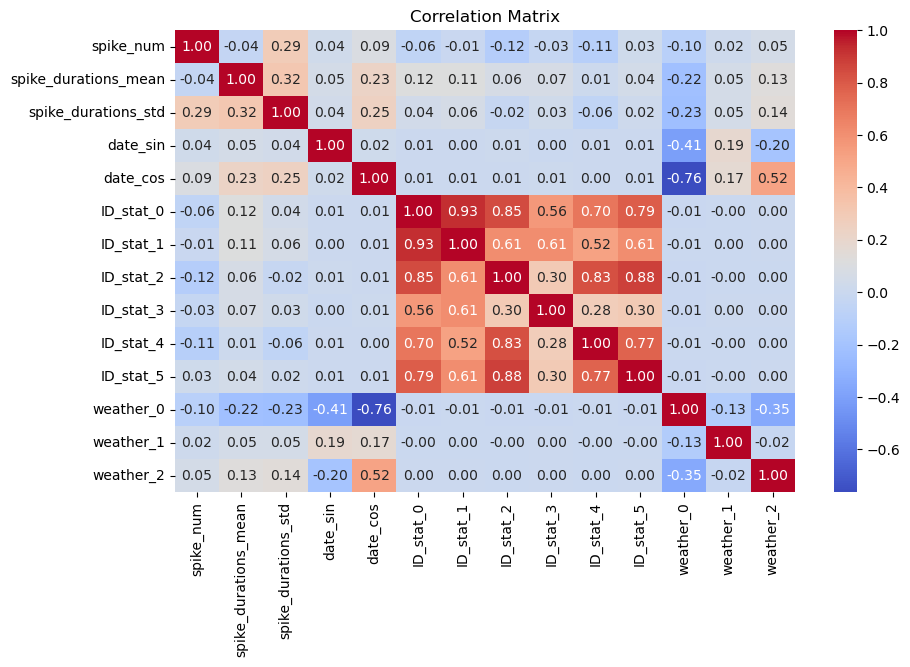

In [26]:
correlation_matrix = features_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


In [27]:
spike_durations_mean = features_df['spike_durations_mean']
spike_durations_mean_norm = (spike_durations_mean - spike_durations_mean.mean()) / spike_durations_mean.std()

spike_durations_std = features_df['spike_durations_std']
spike_durations_std_norm = (spike_durations_std - spike_durations_std.mean()) / spike_durations_std.std()

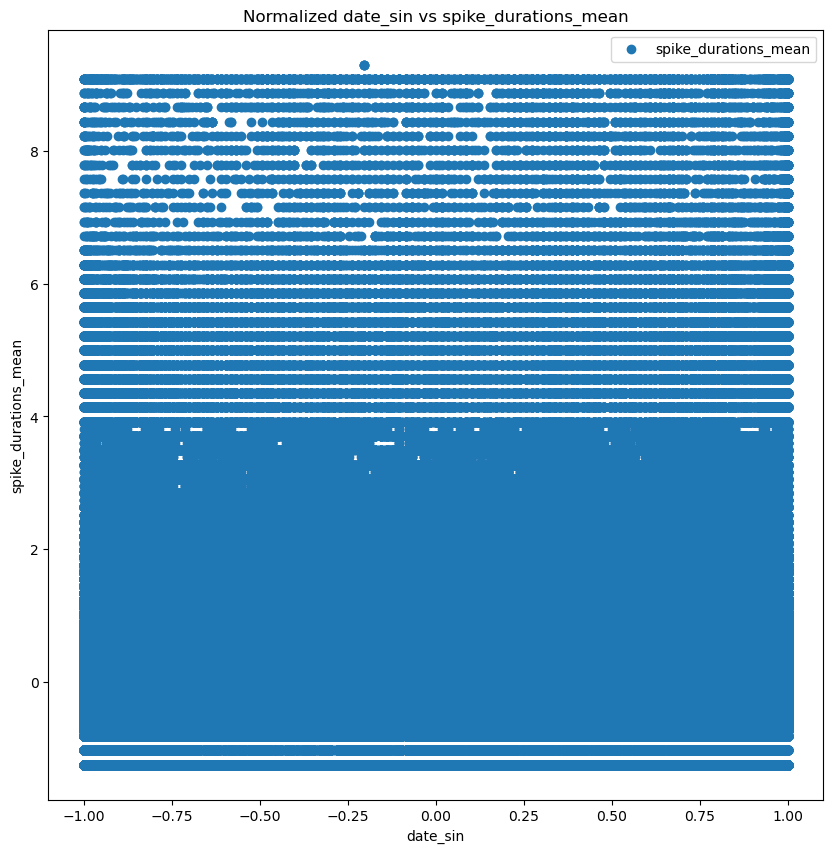

In [28]:
plt.figure(figsize=(10, 10))
plt.scatter(date_sin_norm, spike_durations_mean_norm, label='spike_durations_mean')
plt.title('Normalized date_sin vs spike_durations_mean')
plt.ylabel('spike_durations_mean')
plt.xlabel('date_sin')
plt.legend()

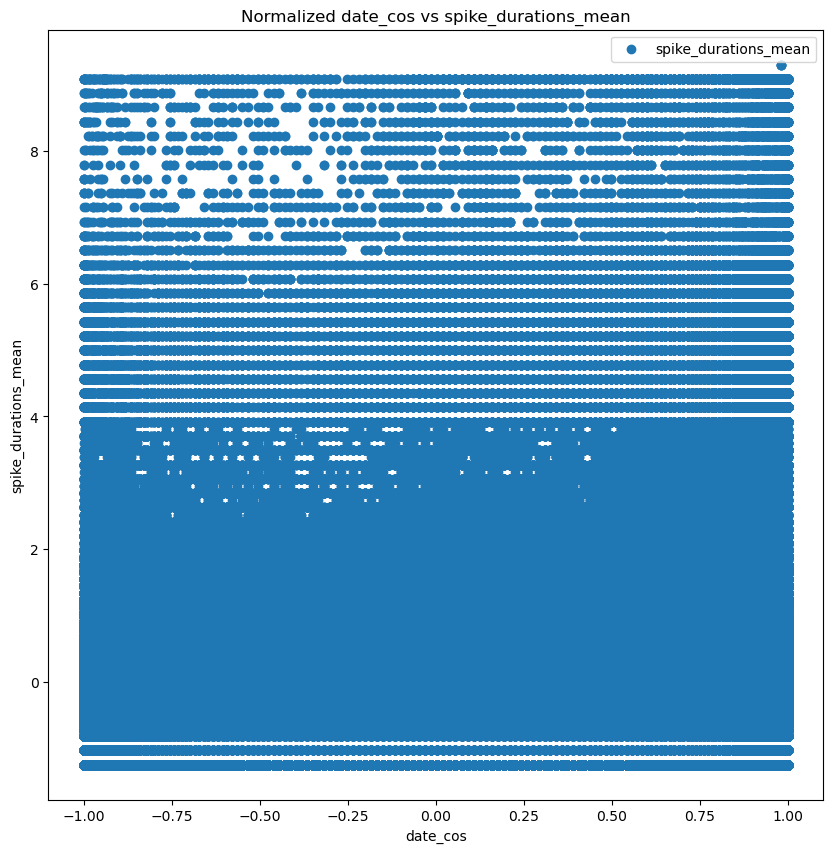

In [29]:
plt.figure(figsize=(10, 10))
plt.scatter(date_cos_norm, spike_durations_mean_norm, label='spike_durations_mean')
plt.title('Normalized date_cos vs spike_durations_mean')
plt.ylabel('spike_durations_mean')
plt.xlabel('date_cos')
plt.legend()

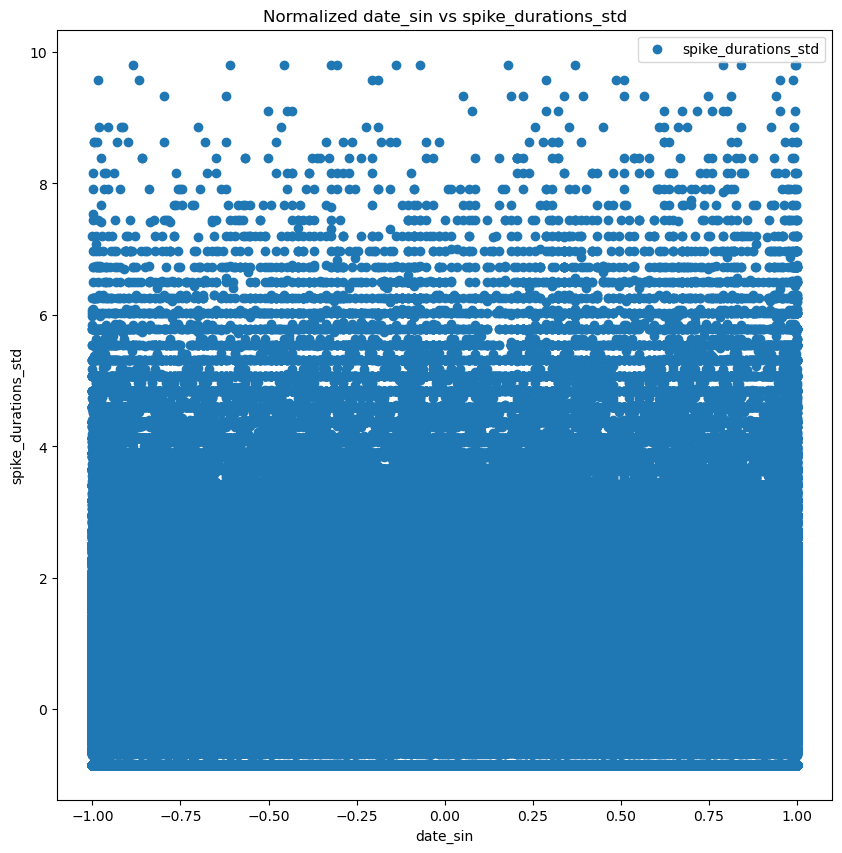

In [30]:
plt.figure(figsize=(10, 10))
plt.scatter(date_sin_norm, spike_durations_std_norm, label='spike_durations_std')
plt.title('Normalized date_sin vs spike_durations_std')
plt.ylabel('spike_durations_std')
plt.xlabel('date_sin')
plt.legend()
plt.show()

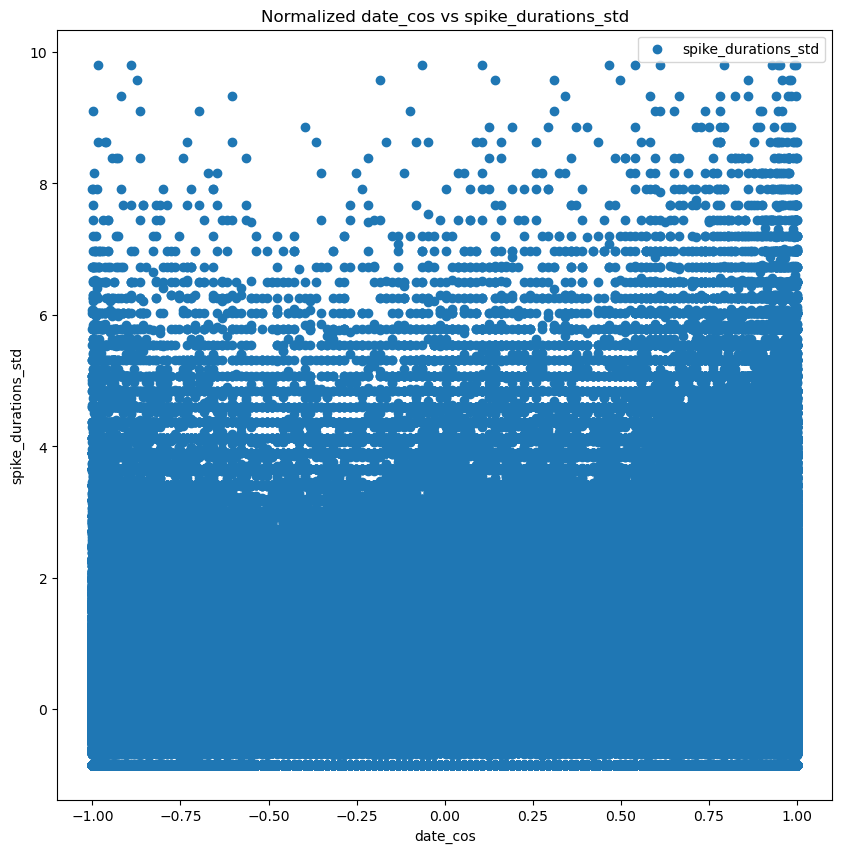

In [31]:
plt.figure(figsize=(10, 10))
plt.scatter(date_cos_norm, spike_durations_std_norm, label='spike_durations_std')
plt.title('Normalized date_cos vs spike_durations_std')
plt.ylabel('spike_durations_std')
plt.xlabel('date_cos')
plt.legend()
plt.show()


# Spike Time

In [37]:
time_df = spike_df[['spike_times_intervals', 'ID-statistics', 'weather', 'date_sin', 'date_cos']]
print(time_df.head())

  spike_times_intervals                                      ID-statistics  \
0          [24, 34, 38]  [0.2525107493475829, 0.158, 0.2470795043314368...   
1              [20, 36]  [0.2525107493475829, 0.158, 0.2470795043314368...   
2              [20, 37]  [0.2525107493475829, 0.158, 0.2470795043314368...   
3      [17, 23, 34, 38]  [0.2525107493475829, 0.158, 0.2470795043314368...   
4          [18, 25, 36]  [0.2525107493475829, 0.158, 0.2470795043314368...   

                                             weather  date_sin  date_cos  
0  [0.44636145833333335, 0.3711697916666667, 0.66... -0.977848  0.209315  
1  [0.37326145833333335, 0.1712510416666667, 0.80... -0.974100  0.226116  
2  [0.35165416666666666, 0.17661875000000002, 0.7... -0.970064  0.242850  
3     [0.392646875, 0.22844895833333334, 0.79748125] -0.965740  0.259512  
4  [0.45284687500000004, 0.3914020833333333, 0.65... -0.961130  0.276097  


In [39]:
# duration_df.loc[:, 'spike_durations_mean'] = duration_df['spike_durations'].apply(lambda x: np.mean(x) if len(x) > 0 else 0)
# duration_df.loc[:, 'spike_durations_std'] = duration_df['spike_durations'].apply(lambda x: np.std(x) if len(x) > 0 else 0)
time_df['spike_times_intervals'] = time_df['spike_times_intervals'].apply(ast.literal_eval)
time_df.loc[:, 'time_mean'] = time_df['spike_times_intervals'].apply(lambda x: np.mean(x) if len(x) > 0 else 0)
time_df.loc[:, 'time_std'] = time_df['spike_times_intervals'].apply(lambda x: np.std(x) if len(x) > 0 else 0)
print(time_df.head())

C:\Users\edwar\AppData\Local\Temp\ipykernel_31568\2954639111.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  time_df['spike_times_intervals'] = time_df['spike_times_intervals'].apply(ast.literal_eval)
C:\Users\edwar\AppData\Local\Temp\ipykernel_31568\2954639111.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  time_df.loc[:, 'time_mean'] = time_df['spike_times_intervals'].apply(lambda x: np.mean(x) if len(x) > 0 else 0)


  spike_times_intervals                                      ID-statistics  \
0          [24, 34, 38]  [0.2525107493475829, 0.158, 0.2470795043314368...   
1              [20, 36]  [0.2525107493475829, 0.158, 0.2470795043314368...   
2              [20, 37]  [0.2525107493475829, 0.158, 0.2470795043314368...   
3      [17, 23, 34, 38]  [0.2525107493475829, 0.158, 0.2470795043314368...   
4          [18, 25, 36]  [0.2525107493475829, 0.158, 0.2470795043314368...   

                                             weather  date_sin  date_cos  \
0  [0.44636145833333335, 0.3711697916666667, 0.66... -0.977848  0.209315   
1  [0.37326145833333335, 0.1712510416666667, 0.80... -0.974100  0.226116   
2  [0.35165416666666666, 0.17661875000000002, 0.7... -0.970064  0.242850   
3     [0.392646875, 0.22844895833333334, 0.79748125] -0.965740  0.259512   
4  [0.45284687500000004, 0.3914020833333333, 0.65... -0.961130  0.276097   

   time_mean  time_std  
0  32.000000  5.887841  
1  28.000000  8.000000  

C:\Users\edwar\AppData\Local\Temp\ipykernel_31568\2954639111.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  time_df.loc[:, 'time_std'] = time_df['spike_times_intervals'].apply(lambda x: np.std(x) if len(x) > 0 else 0)


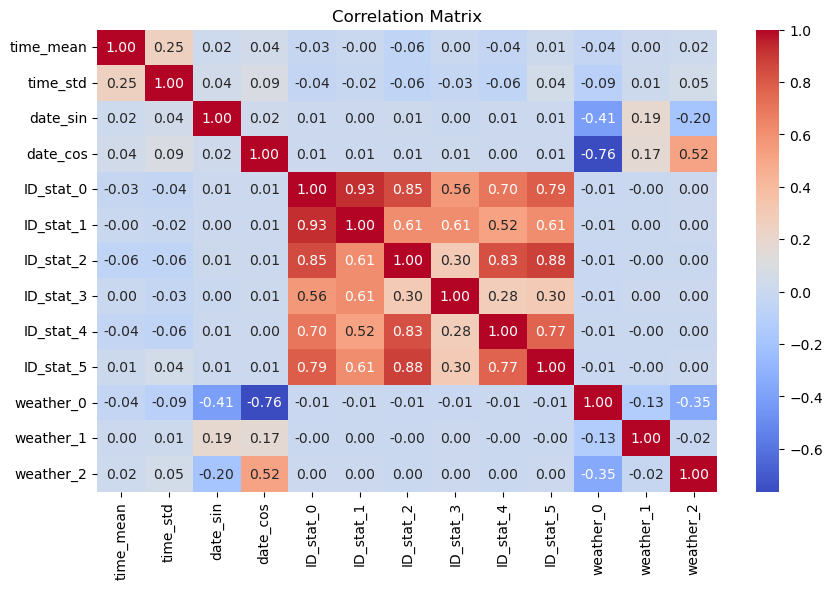

In [41]:
features_df = pd.concat([time_df[['time_mean', 'time_std', 'date_sin', 'date_cos']], id_stats_df, weather_df], axis=1)

correlation_matrix = features_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()